# **MID SEMESTER DATA ANALYTICS**

## **Setup and Configuration**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, pointbiserialr
from scipy.stats import chi2_contingency, f_oneway
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score, classification_report, confusion_matrix

## **Data Understanding & Quality Assessment**

#### **Data Loading**

In [ ]:
df = pd.read_excel("Telco_customer_churn (1).xlsx")

#### **Describe the Dataset**

Dataset Preview

In [ ]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


Dataset Structure

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Descriptive Statistics

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


#### **Identifying Data Quality Issues**

Missing values

In [ ]:
pd.DataFrame({
    "missing values" : df.isnull().sum(),
    "missing values percentage" : df.isnull().sum() / len(df) * 100
})

,missing values,missing values percentage
CustomerID,0,0.000000
Count,0,0.000000
Country,0,0.000000
State,0,0.000000
City,0,0.000000
Zip Code,0,0.000000
Lat Long,0,0.000000
Latitude,0,0.000000
Longitude,0,0.000000
Gender,0,0.000000


Wrong Datatypes and Inconsistencies Found

Outliers Found

In [ ]:
numerical_col_pre_eda = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_col_pre_eda = df.select_dtypes(include='object').columns.tolist()

print(numerical_col_pre_eda)
print(categorical_col_pre_eda)

['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Label', 'Churn Reason']


In [ ]:
exception_col = ['Count', 'Zip Code', 'Latitude', 'Longitude', 'Churn Value']
outlier_check_col = [col for col in numerical_col_pre_eda if col not in exception_col]

print(outlier_check_col)

['Tenure Months', 'Monthly Charges', 'Churn Score', 'CLTV']


In [ ]:
df['is_outlier'] = False

for col in outlier_check_col:
    Q3 = df[col].quantile(0.75)
    Q1 = df[col].quantile(0.25)
    IQR = Q3 - Q1

    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR

    # Menggunakan df bukan df_eda
    outlier_condition = (df[col] < lower) | (df[col] > upper)
    df.loc[outlier_condition, 'is_outlier'] = True

print(f"Rows with outlier: {df['is_outlier'].sum()}")

Rows with outlier: 0


Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

## **Data Wrangling & Preperation Process**

#### **Preparing Dataset for EDA**

In [ ]:
df_eda = df.copy()

#### **Cleaning the Dataset**

Dropping irrelevant columns for EDA

In [ ]:
cat_drop = ['CustomerID', 'Lat Long', 'Country', 'State', 'Churn Reason']
num_drop = ['Count', 'Zip Code', 'Latitude', 'Longitude', 'Churn Value']

df_eda.drop(columns=cat_drop, inplace=True)
df_eda.drop(columns=num_drop, inplace=True)

Missing Value

In [ ]:
df_eda['Total Charges'] = df_eda['Total Charges'].replace(' ', 0)

/tmp/ipykernel_1574/485355483.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_eda['Total Charges'] = df_eda['Total Charges'].replace(' ', 0)


Wrong Datatypes and Inconsistencies

In [ ]:
df_eda['Total Charges'] = pd.to_numeric(df_eda['Total Charges'])

Outlier

In [ ]:
numerical_col = df_eda.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_col = df_eda.select_dtypes(include='object').columns.tolist()

print(numerical_col)
print(categorical_col)

['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']
['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label']


In [ ]:
exception_col = ['Count', 'Zip Code', 'Latitude', 'Longitude', 'Churn Value']
outlier_check_col = [col for col in numerical_col if col not in exception_col]

print(outlier_check_col)

['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']


In [ ]:
for col in outlier_check_col:
    Q3 = df_eda[col].quantile(0.75)
    Q1 = df_eda[col].quantile(0.25)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    df_eda = df_eda[(df_eda[col] >= lower) & df_eda[col] <= upper]

df_eda = df_eda.reset_index(drop=True)

Duplicate

In [ ]:
df_eda = df_eda.drop_duplicates().reset_index(drop=True)

## **Exploritary Data Analysis (EDA)**

Descriptive Statistics

In [ ]:
df_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure Months,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
Monthly Charges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
Total Charges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80
Churn Score,7043.0,58.699418,21.525131,5.00,40.00,61.00,75.00,100.00
CLTV,7043.0,4400.295755,1183.057152,2003.00,3469.00,4527.00,5380.50,6500.00


Univariate: Categorical Columns

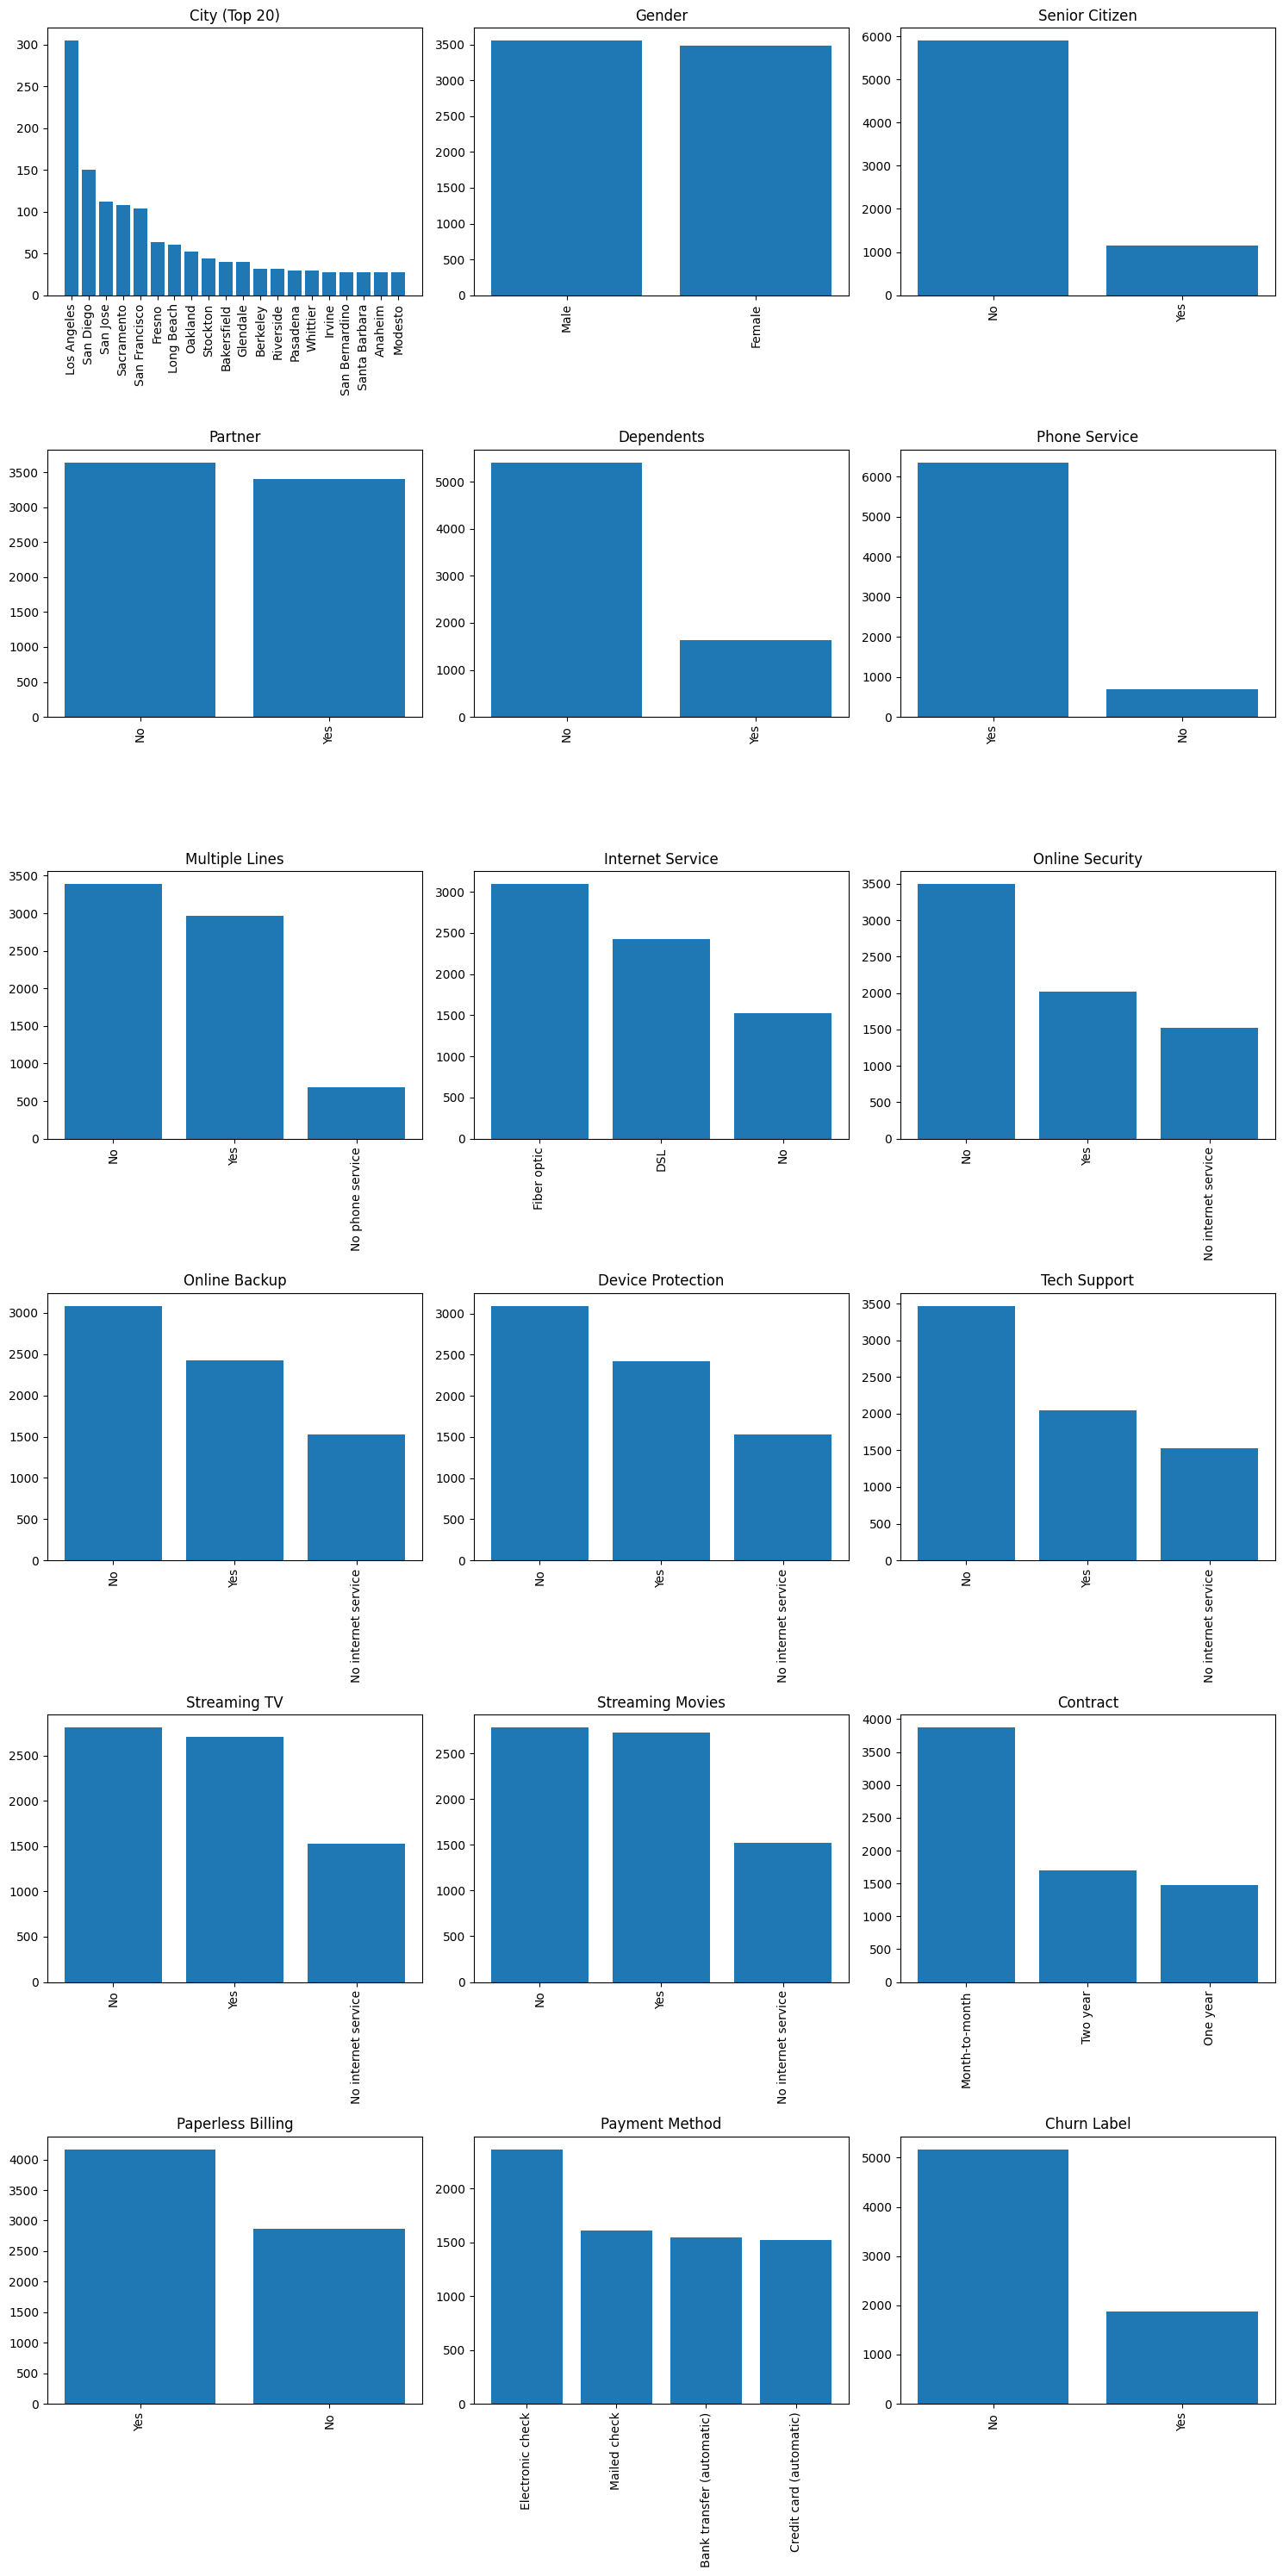

In [ ]:
def check_univariate_cat(df_eda, catCols, top_n=20):
    n = len(catCols)
    rows = -(-n//3)
    plt.figure(figsize=(15, 5 * rows))
    for i, col in enumerate(catCols, 1):
        plt.subplot(rows, 3, i)
        counts = df_eda[col].value_counts()
        if len(counts) > top_n:
            counts = counts.head(top_n)
            plt.title(f'{col} (Top {top_n})')
        else:
            plt.title(col)
        plt.bar(counts.index, counts.values)
        plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

check_univariate_cat(df_eda, categorical_col)

Univaritate: Numerical Column

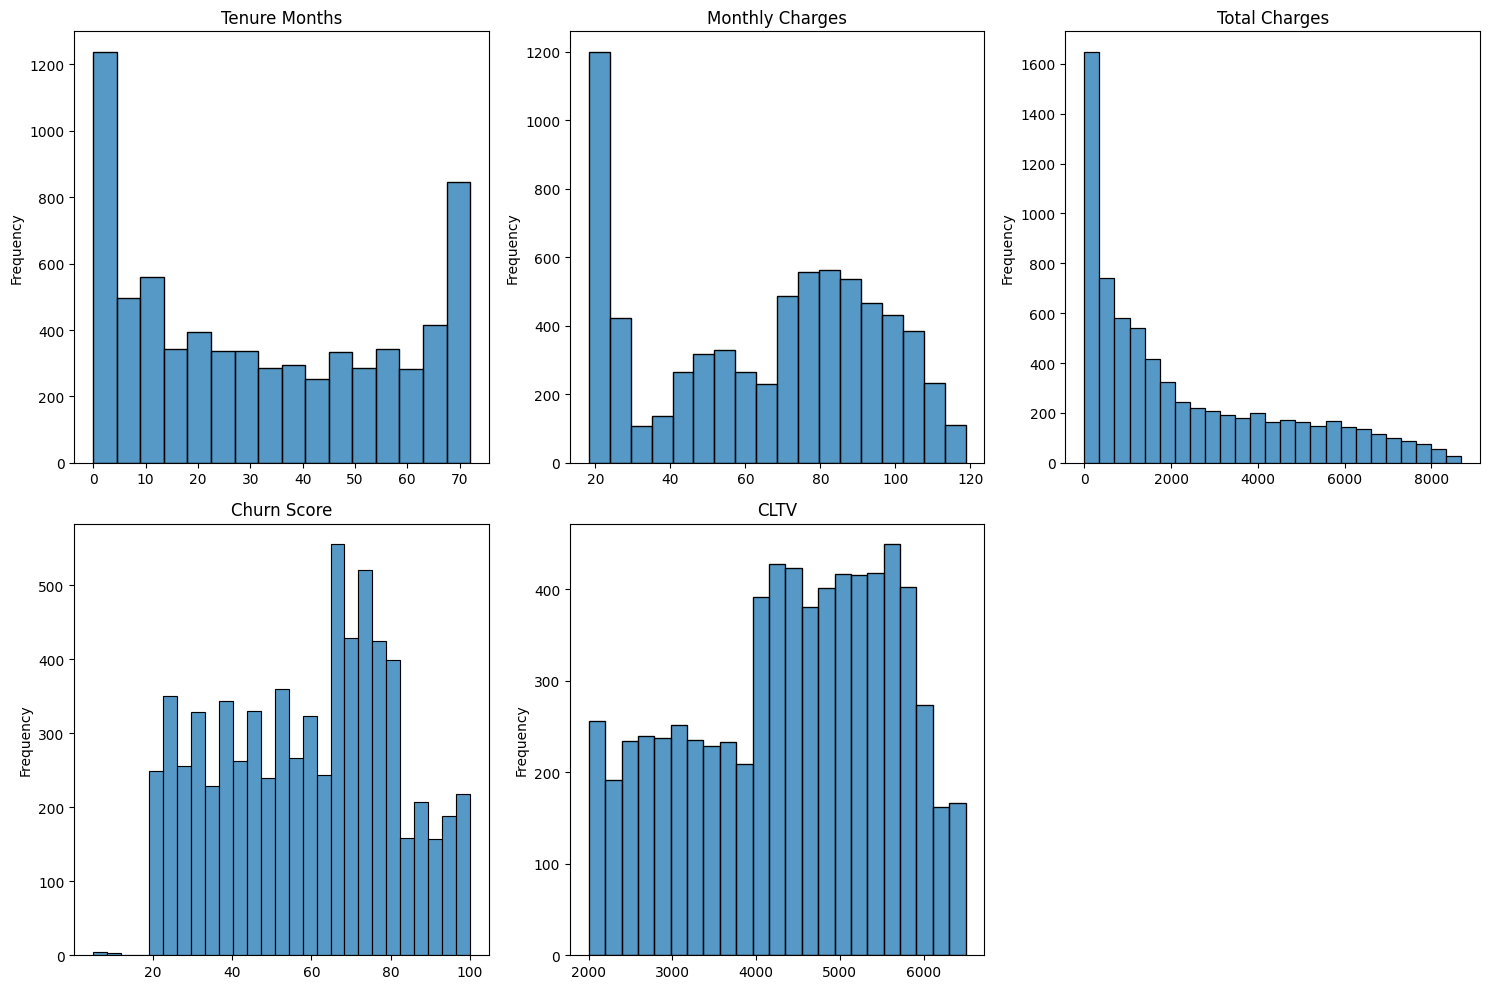

In [ ]:
def check_univariate_num(df_eda, numCols):
    n = len(numCols)
    rows = -(-n // 3)
    plt.figure(figsize=(15, 5 * rows))
    for i, col in enumerate(numCols, 1):
        plt.subplot(rows, 3, i)
        sns.histplot(df_eda[col])
        plt.title(col)
        plt.xlabel('')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

check_univariate_num(df_eda, numerical_col)

Bivariate Numerical Column

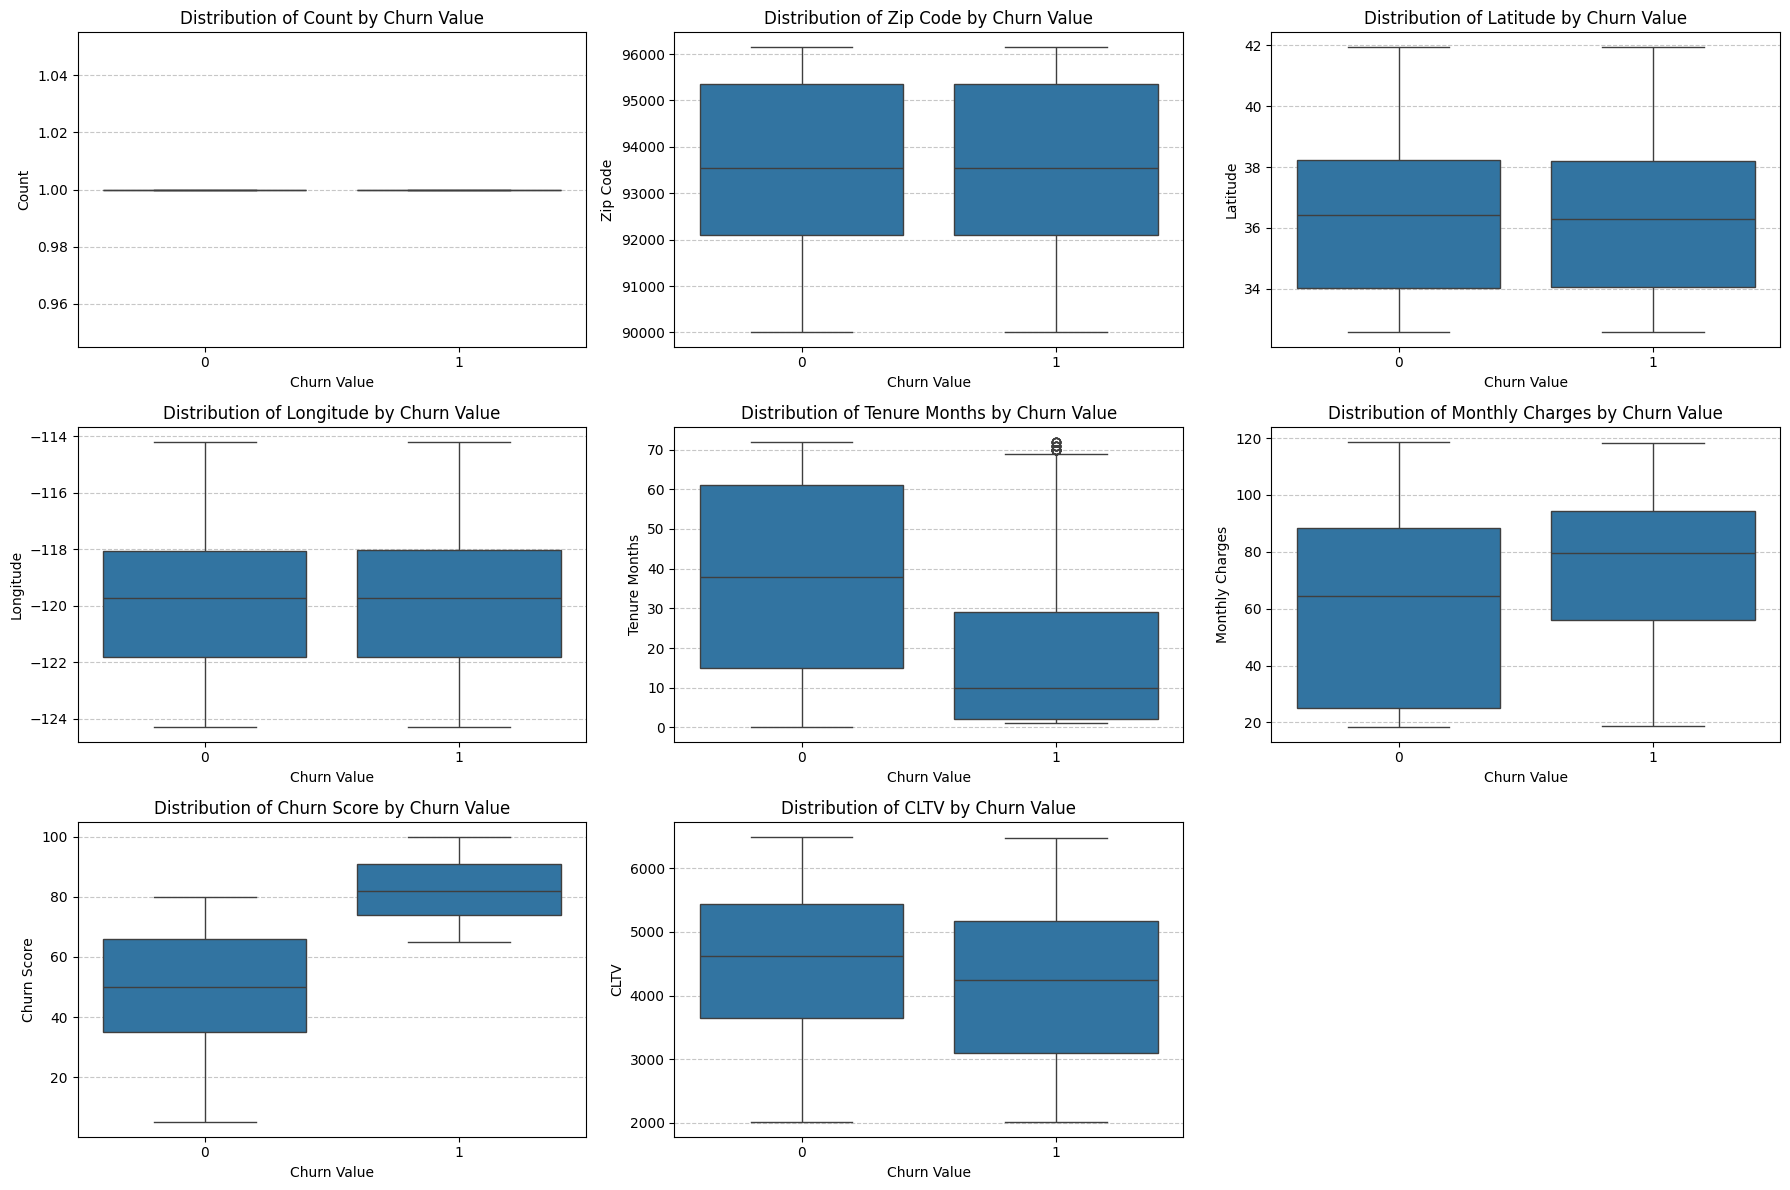

In [ ]:
TARGETCLASS = 'Churn Value'
def check_biv_class_num(df_eda, targetCol, numCol):
    numCol_to_plot = [col for col in numCol if col != targetCol]
    n = len(numCol_to_plot)
    rows = -(-n // 3)
    plt.figure(figsize=(18, 4 * rows))
    for i, col in enumerate(numCol_to_plot, 1):
        plt.subplot(rows, 3, i)
        sns.boxplot(data=df_eda, x=targetCol, y=col)
        plt.title(f'Distribution of {col} by {targetCol}')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

check_biv_class_num(df_eda=df, targetCol=TARGETCLASS, numCol=numerical_col_pre_eda)

Bivariate Categorical Column

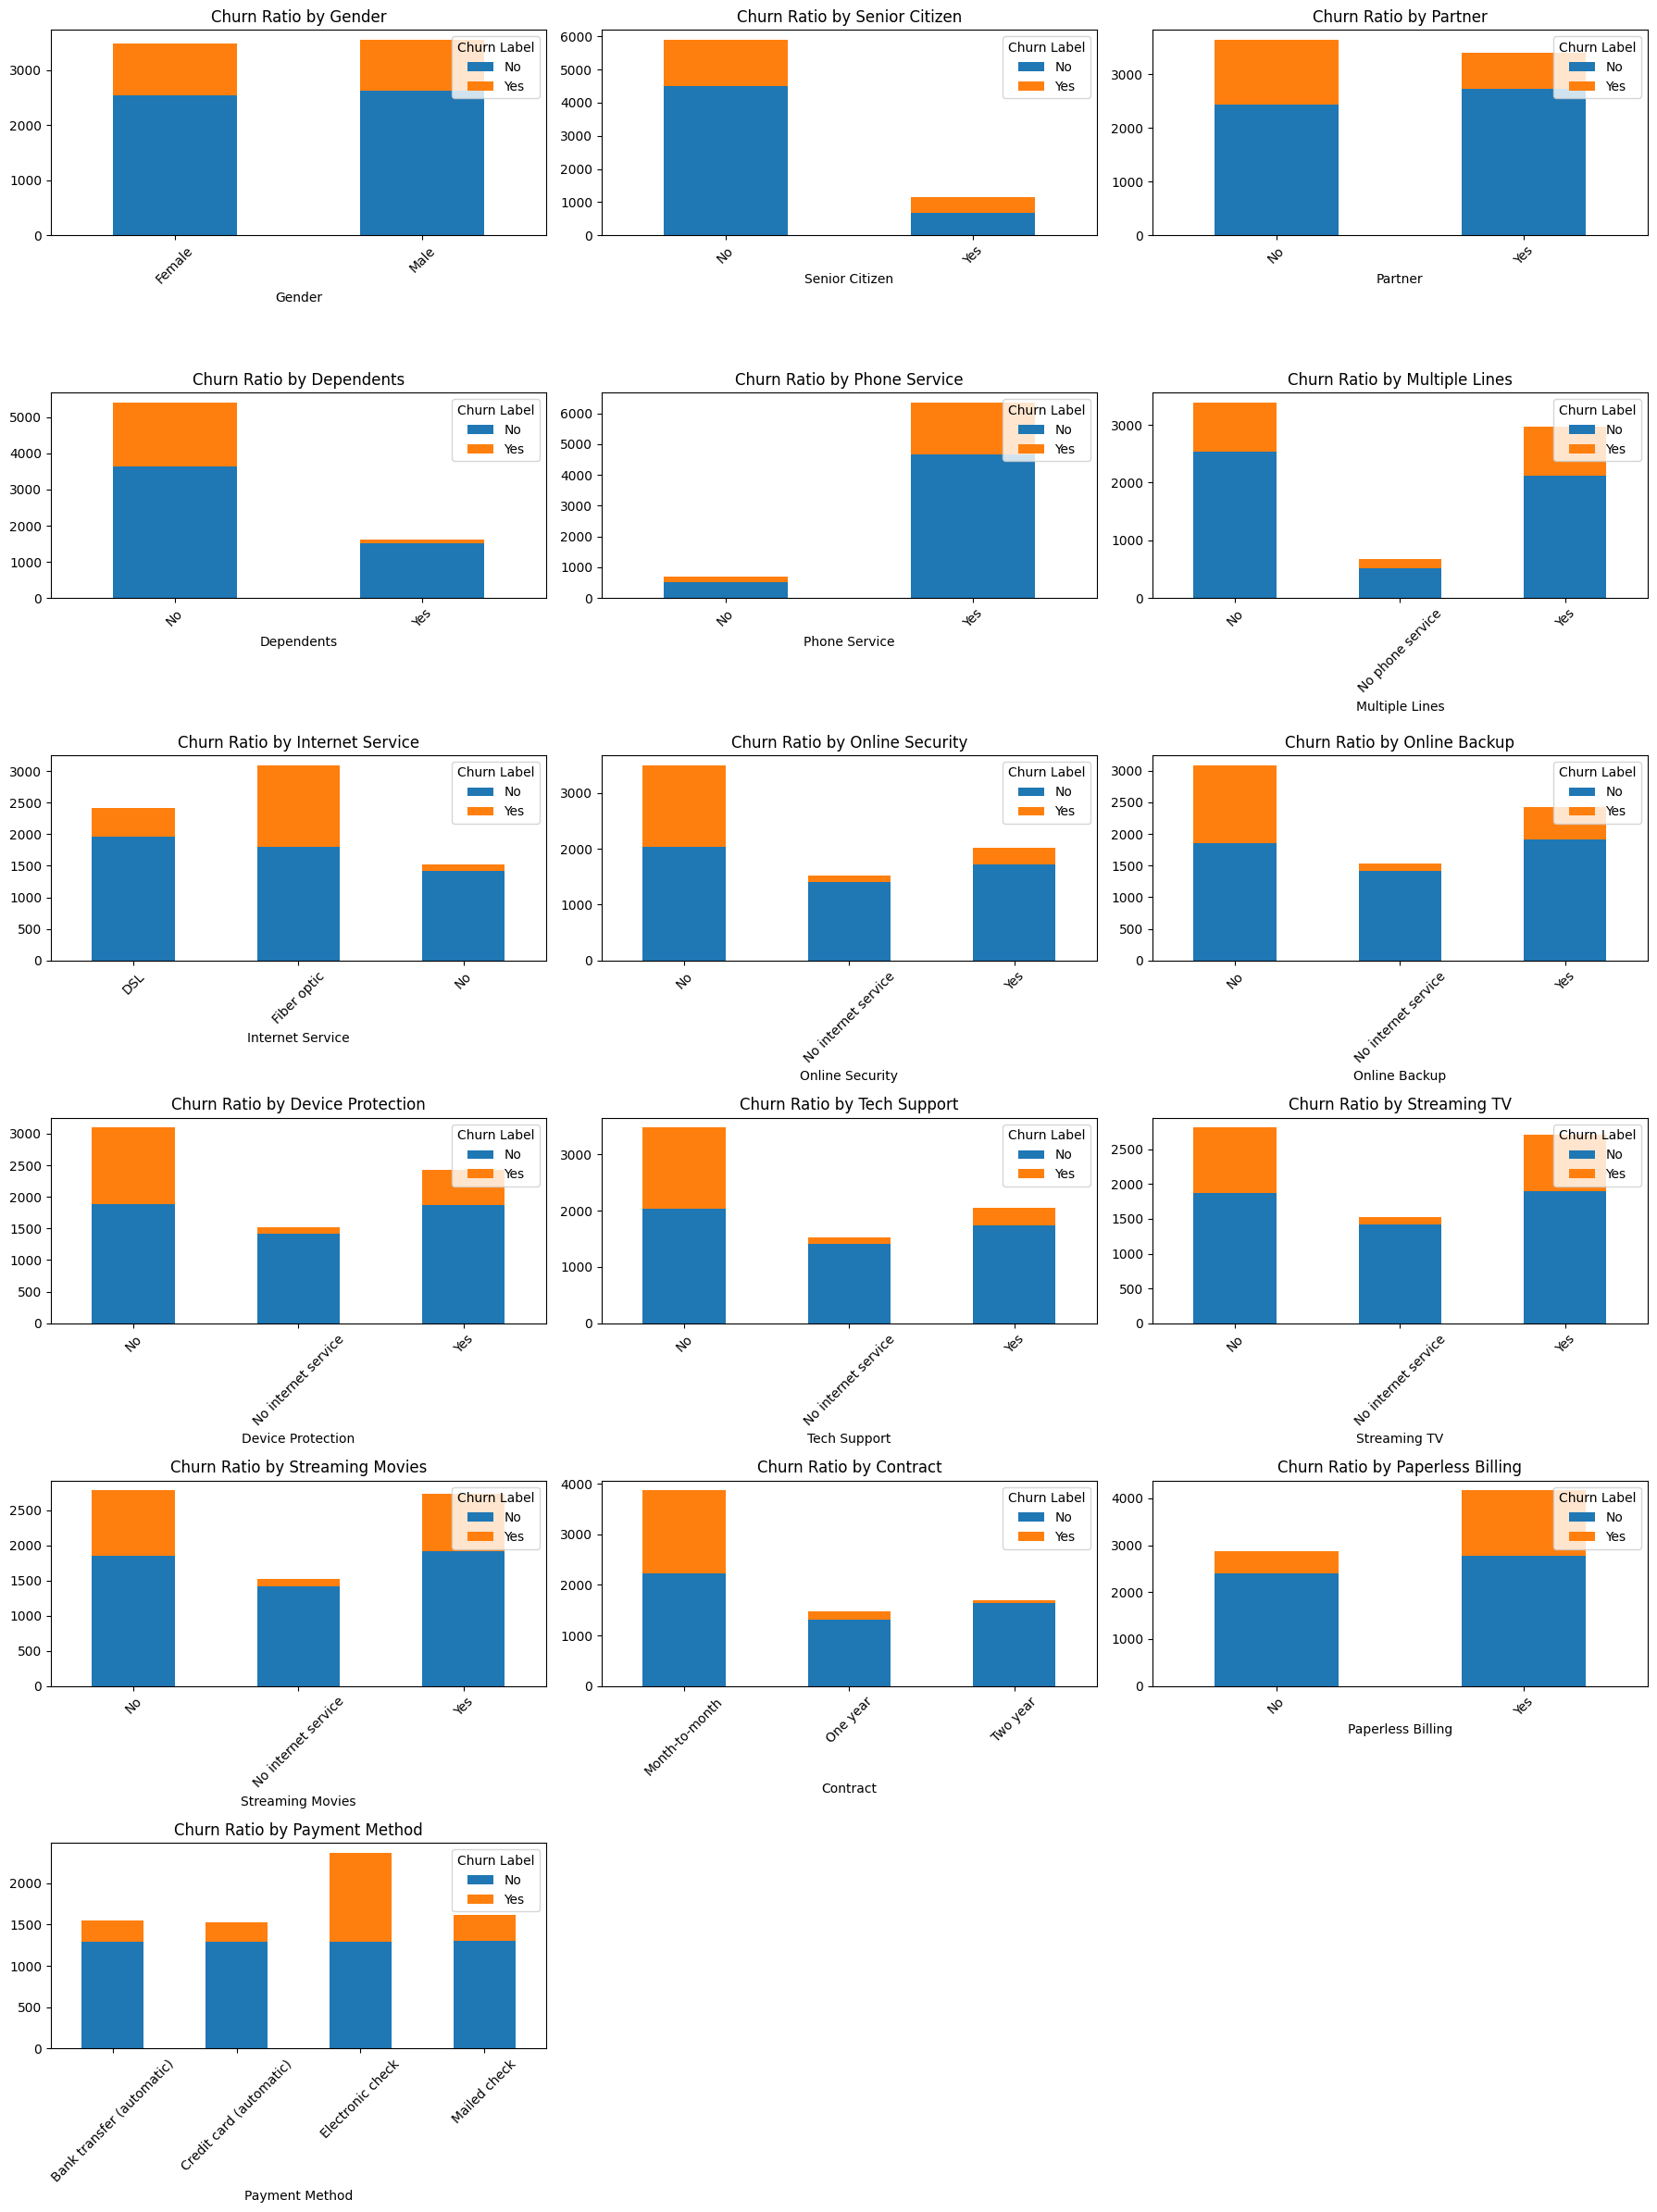

In [ ]:
TARGETCLASS = 'Churn Label'

def check_biv_class_cat(df_eda, targetCol, catCol):
    catCol_to_plot = [col for col in catCol if col not in [targetCol, 'City']]
    n = len(catCol_to_plot)
    rows = -(-n // 3)
    plt.figure(figsize=(18, 4 * rows))
    for i, col in enumerate(catCol_to_plot, 1):
        plt.subplot(rows, 3, i)
        pd.crosstab(df_eda[col], df_eda[targetCol]).plot(kind='bar', stacked=True, ax=plt.gca())
        plt.title(f'Churn Ratio by {col}')
        plt.xticks(rotation=45)
        plt.legend(title=targetCol, loc='upper right')
    plt.tight_layout()
    plt.show()

check_biv_class_cat(df_eda=df_eda, targetCol=TARGETCLASS, catCol=categorical_col)